      SINGLE SERVER QUEUE SIMULATION
Mean Interarrival Time : 2.0
Mean Service Time      : 1.5
Customers Simulated    : 1000
Average Delay          : 0.101
Average Queue Length   : 0.050
Server Utilization     : 0.744
Simulation End Time    : 2033.338


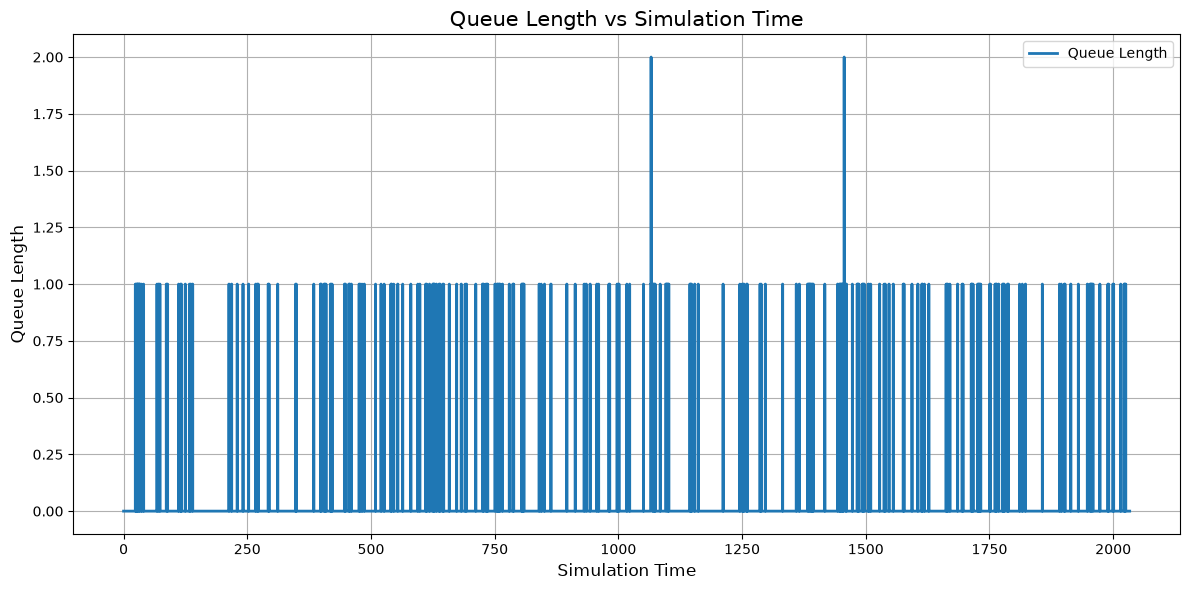

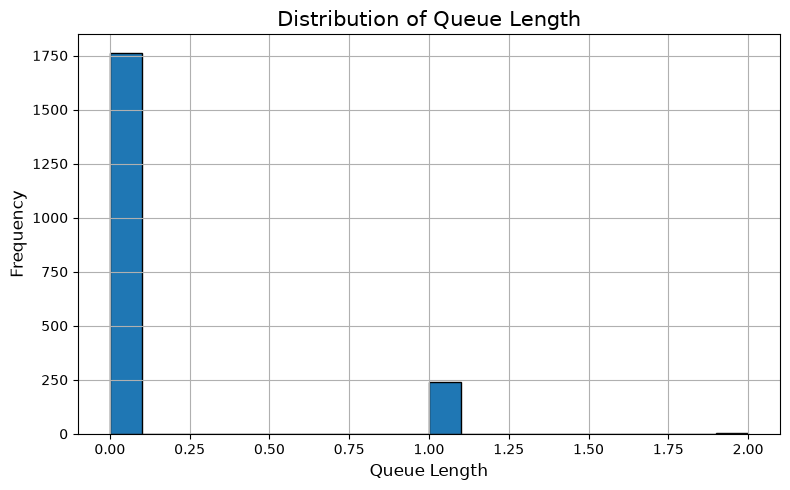

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Parameters
# -------------------------------
MEAN_INTERARRIVAL = 2.0
STD_INTERARRIVAL = 0.5

MEAN_SERVICE = 1.5
STD_SERVICE = 0.3

N_CUSTOMERS = 1000

# -------------------------------
# Initialization
# -------------------------------
clock = 0.0
server_busy = False
queue = []

area_Q = 0.0
area_B = 0.0
total_delay = 0.0

customers_departed = 0

# First Arrival
next_arrival = max(
    0.01,
    np.random.normal(MEAN_INTERARRIVAL, STD_INTERARRIVAL)
)

next_departure = float("inf")

# Data for Graph
time_points = [0.0]
queue_lengths = [0]

# -------------------------------
# Simulation
# -------------------------------
while customers_departed < N_CUSTOMERS:

    next_event_time = min(next_arrival, next_departure)

    area_Q += len(queue) * (next_event_time - clock)
    area_B += (1 if server_busy else 0) * (next_event_time - clock)

    clock = next_event_time

    # ---------------- Arrival ----------------
    if next_arrival <= next_departure:

        if not server_busy:

            server_busy = True

            service_time = max(
                0.01,
                np.random.normal(MEAN_SERVICE, STD_SERVICE)
            )

            next_departure = clock + service_time

        else:

            queue.append(clock)

        next_arrival = clock + max(
            0.01,
            np.random.normal(MEAN_INTERARRIVAL, STD_INTERARRIVAL)
        )

    # ---------------- Departure ----------------
    else:

        customers_departed += 1

        if queue:

            arrival_time = queue.pop(0)

            delay = clock - arrival_time
            total_delay += delay

            service_time = max(
                0.01,
                np.random.normal(MEAN_SERVICE, STD_SERVICE)
            )

            next_departure = clock + service_time

        else:

            server_busy = False
            next_departure = float("inf")

    # Store Data
    time_points.append(clock)
    queue_lengths.append(len(queue))

# -------------------------------
# Performance Measures
# -------------------------------
avg_delay = total_delay / N_CUSTOMERS
avg_queue = area_Q / clock
utilization = area_B / clock
end_time = clock

print("=" * 45)
print("      SINGLE SERVER QUEUE SIMULATION")
print("=" * 45)

print(f"Mean Interarrival Time : {MEAN_INTERARRIVAL}")
print(f"Mean Service Time      : {MEAN_SERVICE}")
print(f"Customers Simulated    : {N_CUSTOMERS}")
print(f"Average Delay          : {avg_delay:.3f}")
print(f"Average Queue Length   : {avg_queue:.3f}")
print(f"Server Utilization     : {utilization:.3f}")
print(f"Simulation End Time    : {end_time:.3f}")

print("=" * 45)

# =====================================================
# Graph 1 : Queue Length vs Time
# =====================================================

plt.figure(figsize=(12,6))

plt.step(
    time_points,
    queue_lengths,
    where="post",
    linewidth=2,
    label="Queue Length"
)

plt.fill_between(
    time_points,
    queue_lengths,
    step="post",
    alpha=0.3
)

plt.xlabel("Simulation Time", fontsize=12)
plt.ylabel("Queue Length", fontsize=12)
plt.title("Queue Length vs Simulation Time", fontsize=15)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# =====================================================
# Graph 2 : Queue Length Distribution
# =====================================================

plt.figure(figsize=(8,5))

plt.hist(
    queue_lengths,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Queue Length", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Queue Length", fontsize=15)

plt.grid(True)

plt.tight_layout()
plt.show()